# Content-Based Phishing Detection — Complete Reproducible Pipeline

**Paper:** *Beyond URL Analysis: Evaluating Content-Based Phishing Detection Using HTML Structural Features*
**Authors:** Al-Haj, Al-Falah, Mohammed, Gebel, Obaid — AITA Journal
**Notebook version:** v6 — paper-scale local execution with auto-resume

---

| § | Section | Paper ref | Notes |
|---|---------|-----------|-------|
| 0 | Install & imports | — | Works on local Jupyter + Colab |
| 1 | Configuration | §III-B, III-D | TARGET_PER_CLASS = 20,000 (paper-scale) |
| 2 | Data sources (PhishTank + Tranco) | §III-B | Auto-download + local file fallback |
| 3 | Robust HTML fetcher | §III-B | 10s timeout, single retry |
| 4 | Feature extraction — d=15 | §III-C | Distinct keyword count via tldextract |
| 5 | Dataset collection loop | §III-B | Auto-resume from checkpoint on crash |
| 6 | EDA & quality report | §III-B | — |
| 7 | Preprocessing pipeline | §III-D | Non-default hyperparameters documented |
| 8 | 5-Fold CV — 7 classifiers | §III-D | Explicit `average='binary'` metrics |
| 9 | Descriptive model comparison | §IV-A | Wilcoxon p≥0.0625 acknowledged |
| 10 | ROC curves — Figure 1 | §IV-B | Aggregated out-of-fold ROC |
| 11 | Aggregated confusion matrices | §IV-C | N=600 normalized + per-class reports |
| 12 | Permutation importance — Table 6 | §IV-D | — |
| 13 | SHAP: global + per-class + dependence | §IV-D | — |
| 14 | Ablation study — Table 7 | §IV-E | — |
| 15 | Qualitative error analysis | §IV-G | FN/FP/TP feature profiles |
| 16 | Export all outputs | §III-E | — |

> **Estimated runtime:** ~15-25 hours for paper-scale collection on local machine.
> Analysis cells (§6 onwards) run in ~5-10 minutes after collection is complete.


In [1]:
# Install required packages (works in both Colab and local Jupyter)
import subprocess, sys

packages = [
    "tldextract", "tranco", "beautifulsoup4", "lxml",
    "requests", "shap", "openpyxl", "scikit-learn",
    "numpy", "pandas", "scipy", "matplotlib"
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

print("Installation complete.")


Installation complete.


In [2]:
import os, sys, re, math, time, json, random, hashlib, zipfile, warnings
import datetime
from io import StringIO
from urllib.parse import urlparse, urljoin

import numpy as np
import pandas as pd
import requests
import tldextract
from bs4 import BeautifulSoup
from tranco import Tranco
from scipy.stats import wilcoxon
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc,
    classification_report,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from requests.adapters import HTTPAdapter

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})

print(f"Python {sys.version.split()[0]}")
print(f"scikit-learn {__import__('sklearn').__version__} | "
      f"numpy {np.__version__} | pandas {pd.__version__} | shap {shap.__version__}")
print("All imports OK")


Python 3.11.0
scikit-learn 1.8.0 | numpy 2.4.4 | pandas 3.0.2 | shap 0.51.0
All imports OK


In [3]:
# =============================================================================
# CONFIGURATION  --  edit only this cell
# =============================================================================
from pathlib import Path

# -------------------------------------------------------
# PAPER-SCALE COLLECTION
# -------------------------------------------------------
# Set TARGET_PER_CLASS high enough so the pipeline collects
# as many pages as possible from each source.
# PhishTank typically has ~55K URLs but only ~15-20% are
# still reachable, yielding ~8,000-12,000 phishing pages.
# Tranco legitimate pages have ~20-25% success rate,
# yielding ~15,000-25,000 legitimate pages.
# -------------------------------------------------------
TARGET_PER_CLASS = 20000

# HTTP settings  --  matches paper §III-B:
# "10-second connection timeout, and a single retry per URL"
TIMEOUT_CONNECT  = 5     # TCP connection timeout (seconds)
TIMEOUT_READ     = 10    # Read timeout (seconds) -- matches paper §III-B
MAX_RETRIES      = 1     # Single retry per URL   -- matches paper §III-B
SLEEP_BASE       = 0.3   # Minimum sleep between requests
SLEEP_JITTER     = 0.2   # Random jitter (anti-bot pattern)
MAX_HTML_BYTES   = 2_000_000  # 2 MB -- truncated pages excluded
MIN_HTML_BYTES   = 256   # Pages shorter than this are excluded (paper §III-B)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
}

# Oversampling: fetch 5x candidates to account for ~80% failure rate
OVERSAMPLE_RATIO = 5

# Checkpointing -- saves every N rows (protects against crashes)
CHECKPOINT_EVERY = 50

# ML settings
RANDOM_STATE  = 42
N_FOLDS       = 5
N_ESTIMATORS  = 100  # ensemble base estimators -- paper §III-D

# Paths (auto-detect: Colab uses /content, local uses ./results)
OUT_DIR         = str(Path("/content/results") if Path("/content").exists()
                      else Path("./results"))
DATASET_PATH    = f"{OUT_DIR}/phish_tranco_dataset.csv"
CHECKPOINT_PATH = f"{OUT_DIR}/_checkpoint.csv"
ERRORS_PATH     = f"{OUT_DIR}/errors.csv"
os.makedirs(OUT_DIR, exist_ok=True)

COLLECTION_DATE = datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC")

print(f"Target per class : {TARGET_PER_CLASS:,}")
print(f"Timeout          : connect={TIMEOUT_CONNECT}s / read={TIMEOUT_READ}s")
print(f"Max retries      : {MAX_RETRIES}  (matches paper §III-B)")
print(f"Min HTML bytes   : {MIN_HTML_BYTES}")
print(f"Checkpoint every : {CHECKPOINT_EVERY} rows")
print(f"Collection date  : {COLLECTION_DATE}")
print(f"Output directory : {OUT_DIR}")
print(f"Random seed      : {RANDOM_STATE}")


Target per class : 20,000
Timeout          : connect=5s / read=10s
Max retries      : 1  (matches paper §III-B)
Min HTML bytes   : 256
Checkpoint every : 50 rows
Collection date  : 2026-04-16 20:49 UTC
Output directory : results
Random seed      : 42


## § 2 — Data Sources

**Phishing URLs** — collected from multiple free sources (no registration needed):
- **OpenPhish**: Community phishing feed (https://openphish.com)
- **PhishStats**: Phishing URL statistics (https://phishstats.info)
- **URLhaus**: Malicious URL database by abuse.ch (https://urlhaus.abuse.ch)
- **Local file**: If you have a CSV/TXT file with phishing URLs, place it in the notebook folder

**Tranco** — stable research-grade top-domain ranking for legitimate pages.


In [4]:
def fetch_phishing_urls(limit):
    """
    Load phishing URLs from multiple free sources (no registration needed).
    Sources tried in order:
      1. Local CSV file (if previously downloaded)
      2. OpenPhish (free community feed)
      3. PhishStats API
      4. URLhaus (abuse.ch - malicious URLs including phishing)
    """

    # --- 1. Check for local file first ---
    local_paths = [
        "./online-valid.csv",
        "./phishtank_online_valid.csv",
        "./phishing_urls.csv",
        "./phishing_urls.txt",
        str(Path.home() / "Downloads" / "online-valid.csv"),
        str(Path.home() / "Downloads" / "verified_online.csv"),
    ]
    for p in local_paths:
        if os.path.exists(p):
            print(f"  Found local file: {p}")
            try:
                if p.endswith('.txt'):
                    with open(p) as f:
                        urls = [line.strip() for line in f if line.strip().startswith('http')]
                else:
                    df = pd.read_csv(p, comment="#", low_memory=False)
                    url_col = next((c for c in df.columns if "url" in c.lower()), df.columns[0])
                    urls = df[url_col].dropna().astype(str).str.strip().tolist()
                urls = [u for u in urls if u.startswith("http")]
                if len(urls) > 100:
                    print(f"  Loaded {len(urls):,} URLs from local file")
                    return urls[:limit]
            except Exception as e:
                print(f"  Failed to parse {p}: {e}")

    all_urls = []

    # --- 2. OpenPhish (free community feed) ---
    print("  [1/3] Trying OpenPhish community feed...")
    try:
        r = requests.get("https://openphish.com/feed.txt", timeout=30,
                         headers={"User-Agent": "Mozilla/5.0"})
        if r.status_code == 200:
            urls = [u.strip() for u in r.text.strip().split("\n") if u.strip().startswith("http")]
            all_urls.extend(urls)
            print(f"        Got {len(urls):,} URLs from OpenPhish")
    except Exception as e:
        print(f"        OpenPhish failed: {e}")

    # --- 3. PhishStats (recent phishing URLs) ---
    print("  [2/3] Trying PhishStats API...")
    try:
        r = requests.get("https://phishstats.info/phish_score.csv", timeout=60,
                         headers={"User-Agent": "Mozilla/5.0"})
        if r.status_code == 200:
            lines = r.text.strip().split("\n")
            urls = []
            for line in lines:
                if line.startswith("#") or not line.strip():
                    continue
                parts = line.split(",")
                for part in parts:
                    part = part.strip().strip('"')
                    if part.startswith("http"):
                        urls.append(part)
                        break
            all_urls.extend(urls)
            print(f"        Got {len(urls):,} URLs from PhishStats")
    except Exception as e:
        print(f"        PhishStats failed: {e}")

    # --- 4. URLhaus (abuse.ch - includes phishing) ---
    print("  [3/3] Trying URLhaus (abuse.ch)...")
    try:
        r = requests.get("https://urlhaus.abuse.ch/downloads/csv_online/", timeout=60,
                         headers={"User-Agent": "Mozilla/5.0"})
        if r.status_code == 200:
            urls = []
            for line in r.text.strip().split("\n"):
                if line.startswith("#") or line.startswith('"id"'):
                    continue
                parts = line.split(",")
                for part in parts:
                    part = part.strip().strip('"')
                    if part.startswith("http"):
                        urls.append(part)
                        break
            all_urls.extend(urls)
            print(f"        Got {len(urls):,} URLs from URLhaus")
    except Exception as e:
        print(f"        URLhaus failed: {e}")

    # --- Deduplicate ---
    all_urls = list(dict.fromkeys(all_urls))

    if len(all_urls) < 100:
        raise RuntimeError(
            f"Only {len(all_urls)} phishing URLs collected from all sources.\n"
            "Alternative: manually download phishing URLs and save as 'phishing_urls.txt'\n"
            "(one URL per line) in the same folder as this notebook."
        )

    actual = min(limit, len(all_urls))
    print(f"\n  TOTAL: {len(all_urls):,} unique phishing URLs collected -> using {actual:,}")
    return all_urls[:actual]


def fetch_tranco_domains(n):
    """Fetch top-n legitimate domains from the Tranco ranking."""
    print(f"  Fetching Tranco top-{n:,} domains...")
    t = Tranco(cache=True, cache_dir=".tranco_cache")
    domains = t.list().top(n)
    print(f"  Loaded {len(domains):,} domains")
    return domains


# Execute
PHISH_CANDIDATES = TARGET_PER_CLASS * OVERSAMPLE_RATIO
LEGIT_CANDIDATES = TARGET_PER_CLASS * OVERSAMPLE_RATIO

print("=" * 60)
print("FETCHING DATA SOURCES")
print("=" * 60)
phishtank_urls       = fetch_phishing_urls(PHISH_CANDIDATES)
print()
tranco_domains       = fetch_tranco_domains(LEGIT_CANDIDATES)

# Build URL candidates
legit_url_candidates = []
for d in tranco_domains:
    d = d.strip().strip("/")
    legit_url_candidates.append(f"https://{d}")
    legit_url_candidates.append(f"http://{d}")

phishtank_urls       = list(dict.fromkeys(phishtank_urls))
legit_url_candidates = list(dict.fromkeys(legit_url_candidates))

print(f"\nPhishing candidates  : {len(phishtank_urls):,}")
print(f"Legitimate candidates: {len(legit_url_candidates):,}")
print(f"\nEstimated collection time: depends on available URLs")
print(f"Checkpoints saved every {CHECKPOINT_EVERY} rows")


FETCHING DATA SOURCES
  Found local file: ./online-valid.csv
  Loaded 56,550 URLs from local file

  Fetching Tranco top-100,000 domains...
  Loaded 100,000 domains

Phishing candidates  : 56,492
Legitimate candidates: 200,000

Estimated collection time: depends on available URLs
Checkpoints saved every 50 rows


## § 3 — Robust HTML Fetcher

**Improvements over original code:**
- `requests.Session` for connection reuse and persistent headers
- Separate connect/read timeouts `(5s, 10s)` -- matches paper methodology
- Real `MAX_RETRIES=1` with back-off (transient errors only)
- Returns `(html, final_url, fail_reason)` -- fail_reason logged to `errors.csv`
- URL validation before fetch (empty, non-HTTP, malformed)
- Content-type guard (non-HTML rejected)
- Size guard (pages > 2 MB excluded -- matches paper)
- SSL errors not retried (permanent)

**Failure tag taxonomy (logged to errors.csv):**

| Tag | Meaning |
|-----|---------|
| `empty_url` / `invalid_url` | Malformed or empty input |
| `http_4xx` | HTTP 4xx -- permanent, not retried |
| `http_5xx` | HTTP 5xx -- transient, retried |
| `non_html:...` | Non-HTML content-type |
| `html_too_large` | Page > 2 MB |
| `empty_response` | Empty body |
| `timeout` | Connect or read timeout |
| `ssl_error:...` | SSL/TLS failure |
| `too_many_redirects` | Redirect loop |
| `connection_error:...` | TCP connection failure |
| `request_error:...` | Other requests exception |


In [5]:
# requests.Session: connection reuse + persistent headers
_session = requests.Session()
_session.headers.update(HEADERS)
_session.mount("http://",  HTTPAdapter(max_retries=0))
_session.mount("https://", HTTPAdapter(max_retries=0))


def _is_valid_url(url):
    """Return True if url is a non-empty, parseable HTTP/HTTPS URL."""
    if not isinstance(url, str) or not url.strip():
        return False
    url = url.strip()
    if not url.startswith(("http://", "https://")):
        return False
    try:
        return bool(urlparse(url).netloc)
    except Exception:
        return False


def safe_fetch_html(url):
    """
    Fetch HTML from url with retry logic.

    Parameters
    ----------
    url : str

    Returns
    -------
    (html_text, final_url, fail_reason)
        - html_text  : str or None
        - final_url  : str or None (URL after redirects)
        - fail_reason: None on success, short tag string on failure
    """
    if not _is_valid_url(url):
        tag = "empty_url" if not (url or "").strip() else "invalid_url"
        return None, None, tag

    url = url.strip()
    fail_reason = "unknown_error"

    for attempt in range(MAX_RETRIES + 1):
        try:
            r = _session.get(
                url,
                timeout=(TIMEOUT_CONNECT, TIMEOUT_READ),
                allow_redirects=True,
                stream=False,
            )

            # HTTP 4xx -- permanent, never retry
            if 400 <= r.status_code < 500:
                return None, None, f"http_{r.status_code}"

            # HTTP 5xx -- transient, retry
            if r.status_code >= 500:
                fail_reason = f"http_{r.status_code}"
                if attempt < MAX_RETRIES:
                    time.sleep(1.5 ** attempt + random.uniform(0.2, 0.8))
                    continue
                return None, None, fail_reason

            # Content-type guard
            ctype = (r.headers.get("Content-Type") or "").lower()
            if "text/html" not in ctype and "application/xhtml" not in ctype:
                return None, None, f"non_html:{ctype.split(';')[0].strip()}"

            # Size guard (matches paper: truncated pages excluded)
            raw = r.content
            if len(raw) > MAX_HTML_BYTES:
                return None, None, "html_too_large"

            # Decode
            try:
                html = raw.decode(r.apparent_encoding or "utf-8", errors="replace")
            except Exception:
                html = raw.decode("utf-8", errors="replace")

            if not html.strip():
                return None, None, "empty_response"

            return html, r.url, None   # SUCCESS

        except requests.exceptions.ConnectTimeout:
            fail_reason = "timeout"
        except requests.exceptions.ReadTimeout:
            fail_reason = "timeout"
        except requests.exceptions.SSLError as exc:
            # SSL errors are permanent -- do not retry
            return None, None, f"ssl_error:{type(exc).__name__}"
        except requests.exceptions.TooManyRedirects:
            return None, None, "too_many_redirects"
        except requests.exceptions.ConnectionError as exc:
            fail_reason = f"connection_error:{type(exc).__name__}"
        except requests.exceptions.RequestException as exc:
            fail_reason = f"request_error:{type(exc).__name__}"
        except Exception as exc:
            fail_reason = f"unknown_error:{type(exc).__name__}"

        # Back-off before retry
        if attempt < MAX_RETRIES:
            time.sleep(1.0 + random.uniform(0.2, 0.8))

    return None, None, fail_reason


# Smoke-test
_h, _fu, _err = safe_fetch_html("https://www.google.com")
if _h:
    print(f"Fetcher OK  |  google.com: {len(_h):,} chars  |  final_url: {_fu}")
else:
    print(f"Fetcher test failed: {_err}")


Fetcher OK  |  google.com: 193,372 chars  |  final_url: https://www.google.com/


## § 4 — Feature Extraction (d = 15)

Implements **Table 3** of the paper exactly.
All 15 features derived from HTML source code only — no URL properties.

**Revised in v3:**
- `keyword_hits` counts **distinct keywords present** (binary per keyword), not total occurrences
- External links compared using `tldextract` registered-domain (not urllib.parse netloc)


In [6]:
# Phishing-indicative keywords (Table 3, feature 15)
PHISHING_KEYWORDS = ["verify", "login", "password", "update",
                     "bank", "account", "confirm", "secure"]


def _registered_domain(url):
    """Return 'domain.tld' using tldextract (more accurate than netloc)."""
    try:
        ext = tldextract.extract(url)
        if ext.domain and ext.suffix:
            return f"{ext.domain}.{ext.suffix}".lower()
    except Exception:
        pass
    return ""


def extract_features(seed_url, html, final_url=None):
    """
    Extract the 15 HTML-derived content features (d=15) -- Table 3 in paper.

    Parameters: seed_url (original), html (raw string), final_url (after redirect)
    Returns: dict with 15 numeric keys, all int or float, no NaN/Inf
    """
    base_url    = (final_url or seed_url).strip()
    base_domain = _registered_domain(base_url)

    # Parse full DOM once (for structural + hyperlink features)
    soup = BeautifulSoup(html, "lxml")

    # --- Structural features ---
    n_scripts = len(soup.find_all("script"))
    n_images  = len(soup.find_all("img"))
    n_forms   = len(soup.find_all("form"))
    n_iframes = len(soup.find_all("iframe"))

    inputs      = soup.find_all("input")
    n_inputs    = len(inputs)
    itypes      = [i.get("type", "").lower().strip() for i in inputs]
    has_password_field = int("password" in itypes)
    has_email_field    = int("email" in itypes)
    has_submit_field   = int(
        "submit" in itypes or bool(soup.find("button", attrs={"type": "submit"}))
    )

    # --- Hyperlink features (using registered-domain comparison) ---
    hrefs   = [a.get("href", "") for a in soup.find_all("a") if a.get("href")]
    n_links = len(hrefs)

    def _is_ext(href):
        try:
            abs_h = urljoin(base_url, href.strip())
            p     = urlparse(abs_h)
            if p.scheme not in ("http", "https") or not p.netloc:
                return False
            return _registered_domain(abs_h) not in ("", base_domain)
        except Exception:
            return False

    n_external_links    = sum(_is_ext(h) for h in hrefs) if n_links > 0 else 0
    external_link_ratio = (n_external_links / n_links) if n_links > 0 else 0.0

    # --- Textual features (strip non-visible elements first) ---
    soup_t = BeautifulSoup(html, "lxml")
    for tag in soup_t(["script", "style", "noscript", "head"]):
        tag.decompose()
    for tag in soup_t.find_all(style=True):
        if "display:none" in tag.get("style", "").replace(" ", "").lower():
            tag.decompose()

    visible = soup_t.get_text(" ", strip=True)
    text_len   = len(visible)
    word_count = len(visible.split()) if text_len > 0 else 0

    title_tag  = soup.find("title")
    title_len  = len(title_tag.get_text(strip=True)) if title_tag else 0

    lowered      = visible.lower()
    # Count of DISTINCT keywords present (not total occurrences).
    # e.g., if "verify" appears 10 times, it still counts as 1.
    # This matches the revised paper Table 3 definition.
    # Count of DISTINCT keywords present (not total occurrences).
    # e.g., if "verify" appears 10 times, it still counts as 1.
    # This matches the revised paper Table 3 definition.
    keyword_hits = sum(1 for kw in PHISHING_KEYWORDS if kw in lowered)

    return {
        # Textual (4)
        "text_len"           : int(text_len),
        "word_count"         : int(word_count),
        "title_len"          : int(title_len),
        "keyword_hits"       : int(keyword_hits),
        # Structural (8)
        "n_scripts"          : int(n_scripts),
        "n_images"           : int(n_images),
        "n_forms"            : int(n_forms),
        "n_inputs"           : int(n_inputs),
        "n_iframes"          : int(n_iframes),
        "has_password_field" : int(has_password_field),
        "has_submit_field"   : int(has_submit_field),
        "has_email_field"    : int(has_email_field),
        # Hyperlink (3)
        "n_links"            : int(n_links),
        "n_external_links"   : int(n_external_links),
        "external_link_ratio": float(external_link_ratio),
    }


# Feature metadata
FEATURE_NAMES = [
    "text_len", "word_count", "title_len", "keyword_hits",
    "n_scripts", "n_images", "n_forms", "n_inputs", "n_iframes",
    "has_password_field", "has_submit_field", "has_email_field",
    "n_links", "n_external_links", "external_link_ratio",
]
BINARY_FEATURES     = ["has_password_field", "has_submit_field", "has_email_field"]
CONTINUOUS_FEATURES = [f for f in FEATURE_NAMES if f not in BINARY_FEATURES]

assert len(FEATURE_NAMES) == 15, f"d={len(FEATURE_NAMES)} -- expected 15"


def validate_features(feats):
    """Return (is_valid: bool, reason: str). Rejects NaN, Inf, or negative counts."""
    for k, v in feats.items():
        if not isinstance(v, (int, float)):
            return False, f"non_numeric:{k}"
        if isinstance(v, float) and (np.isnan(v) or np.isinf(v)):
            return False, f"nan_or_inf:{k}"
        if v < 0 and k not in ("external_link_ratio",):
            return False, f"negative:{k}={v}"
    return True, ""


# Smoke-test
_t = "<html><head><title>Login Page</title></head><body>" \
     "<form><input type='password'/><button type='submit'>Go</button></form>" \
     "<a href='https://other.com'>ext</a><img src='x.png'/></body></html>"
_f = extract_features("https://example.com", _t)
_ok, _why = validate_features(_f)
print(f"d = {len(FEATURE_NAMES)} features confirmed")
print(f"Smoke-test: valid={_ok}  has_password={_f['has_password_field']}  "
      f"has_submit={_f['has_submit_field']}  n_external_links={_f['n_external_links']}")


d = 15 features confirmed
Smoke-test: valid=True  has_password=1  has_submit=1  n_external_links=1


## § 5 — Dataset Collection Loop

**All improvements applied:**

| Improvement | Details |
|-------------|---------|
| Failure logging | Every failure logged with `url`, `label`, `stage`, `error` tag |
| Double dedup | `seen_final_urls` (redirect target) + `seen_html_hashes` (content MD5) |
| Feature validation | `validate_features()` rejects NaN/Inf before insert |
| Checkpoint resume | Existing rows loaded; already-seen URLs skipped |
| Target warning | Prints warning if target not reached after all candidates exhausted |
| Exception capture | `except Exception as exc` with type + message in error log |

**Error stages in `errors.csv`:**

| stage | meaning |
|-------|---------|
| `fetch` | HTTP / network failure |
| `dedup_final_url` | Redirect landed on already-collected page |
| `dedup_html_hash` | Same HTML content from different URL |
| `feature_extraction` | Exception inside `extract_features()` |
| `feature_validation` | NaN / Inf / unexpected value in features |


In [7]:
# =============================================================================
# AUTO-RESUME STATE MANAGEMENT
# =============================================================================
# This cell automatically detects and loads any existing checkpoint.
# If the notebook crashes or you close it, just re-run from this cell
# and it will continue from where it stopped.
# =============================================================================

rows             = []
error_rows       = []
seen_final_urls  = set()
seen_html_hashes = set()
stats = {"phish_ok": 0, "phish_fail": 0, "legit_ok": 0, "legit_fail": 0}

# Auto-load checkpoint
if os.path.exists(CHECKPOINT_PATH):
    try:
        _ck = pd.read_csv(CHECKPOINT_PATH, low_memory=False)
        if not _ck.empty and "final_url" in _ck.columns and "label" in _ck.columns:
            rows             = _ck.to_dict("records")
            seen_final_urls  = set(_ck["final_url"].dropna().tolist())
            if "url" in _ck.columns:
                seen_final_urls |= set(_ck["url"].dropna().tolist())
            stats["phish_ok"] = int((_ck["label"] == 1).sum())
            stats["legit_ok"] = int((_ck["label"] == 0).sum())
            print(f"CHECKPOINT LOADED: {len(rows):,} rows recovered")
            print(f"  Phishing : {stats['phish_ok']:,}")
            print(f"  Legitimate: {stats['legit_ok']:,}")
            print(f"  Collection will CONTINUE from this point.")
        else:
            print("Checkpoint file empty -- starting fresh.")
    except Exception as e:
        print(f"Checkpoint corrupted ({e}) -- starting fresh.")
else:
    print("No checkpoint found -- starting fresh collection.")

# Also check if FINAL dataset already exists (collection already done)
if os.path.exists(DATASET_PATH):
    _ds = pd.read_csv(DATASET_PATH, low_memory=False)
    if len(_ds) > len(rows):
        print(f"\nFinal dataset already exists with {len(_ds):,} rows.")
        print("To re-collect, delete the file and re-run.")


def _fmt_t(secs):
    if secs is None:
        return "?"
    s = int(max(0, secs))
    h, r = divmod(s, 3600)
    m, s = divmod(r, 60)
    if h: return f"{h}h{m:02d}m{s:02d}s"
    if m: return f"{m}m{s:02d}s"
    return f"{s}s"


def _save_ckpt():
    try:
        pd.DataFrame(rows).to_csv(CHECKPOINT_PATH, index=False)
        if error_rows:
            pd.DataFrame(error_rows).to_csv(ERRORS_PATH, index=False)
    except Exception as e:
        print(f"\n  WARNING: checkpoint save failed: {e}")


CHECKPOINT LOADED: 39,096 rows recovered
  Phishing : 19,096
  Legitimate: 20,000
  Collection will CONTINUE from this point.


In [8]:
def collect(urls, label, target):
    """
    Fetch and extract features from up to `target` pages of one class.
    Includes automatic crash recovery -- if interrupted, re-running
    this function will skip already-collected URLs.
    """
    cls    = "phishing"   if label == 1 else "legitimate"
    ok_k   = "phish_ok"   if label == 1 else "legit_ok"
    fail_k = "phish_fail" if label == 1 else "legit_fail"

    # How many already collected (from checkpoint)?
    existing = sum(1 for r in rows if r.get("label") == label)
    if existing >= target:
        print(f"[{cls}] Already have {existing}/{target} -- skipping.")
        return existing

    ok        = existing
    attempts  = 0
    t0        = time.time()
    ema       = None
    alpha     = 0.15
    last_ckpt = len(rows)
    consecutive_errors = 0
    MAX_CONSECUTIVE_ERRORS = 200  # pause if too many errors in a row

    for url in urls:
        if ok >= target:
            break
        if url in seen_final_urls:
            continue

        iter_t0  = time.time()
        attempts += 1

        # --- Fetch ---
        try:
            html, final_url, fail_reason = safe_fetch_html(url)
        except Exception as exc:
            html, final_url, fail_reason = None, None, f"crash:{type(exc).__name__}"

        time.sleep(SLEEP_BASE + random.uniform(0.0, SLEEP_JITTER))

        if html is None:
            stats[fail_k] += 1
            error_rows.append({
                "url": url, "final_url": None, "label": label,
                "stage": "fetch", "error": fail_reason, "message": "",
            })
            consecutive_errors += 1

            # Safety pause if too many consecutive errors
            if consecutive_errors >= MAX_CONSECUTIVE_ERRORS:
                print(f"\n  {MAX_CONSECUTIVE_ERRORS} consecutive errors -- "
                      f"saving checkpoint and pausing 30s...")
                _save_ckpt()
                time.sleep(30)
                consecutive_errors = 0

        else:
            consecutive_errors = 0  # reset on success
            final_url = final_url or url

            # --- Dedup: redirect target ---
            if final_url in seen_final_urls:
                stats[fail_k] += 1
                error_rows.append({
                    "url": url, "final_url": final_url, "label": label,
                    "stage": "dedup_final_url", "error": "duplicate_final_url",
                    "message": "",
                })
            else:
                # --- Dedup: HTML content ---
                h_hash = hashlib.md5(html.encode("utf-8", errors="ignore")).hexdigest()
                if h_hash in seen_html_hashes:
                    stats[fail_k] += 1
                    error_rows.append({
                        "url": url, "final_url": final_url, "label": label,
                        "stage": "dedup_html_hash", "error": "duplicate_html",
                        "message": "",
                    })
                else:
                    # --- Feature extraction ---
                    try:
                        feats = extract_features(url, html, final_url=final_url)
                    except Exception as exc:
                        stats[fail_k] += 1
                        error_rows.append({
                            "url": url, "final_url": final_url, "label": label,
                            "stage": "feature_extraction",
                            "error": type(exc).__name__, "message": str(exc)[:300],
                        })
                        feats = None

                    if feats is not None:
                        is_ok, why = validate_features(feats)
                        if not is_ok:
                            stats[fail_k] += 1
                            error_rows.append({
                                "url": url, "final_url": final_url, "label": label,
                                "stage": "feature_validation",
                                "error": why, "message": "",
                            })
                        else:
                            # SUCCESS
                            feats["url"]       = url
                            feats["final_url"] = final_url
                            feats["label"]     = label
                            rows.append(feats)
                            seen_final_urls.add(final_url)
                            seen_html_hashes.add(h_hash)
                            ok += 1
                            stats[ok_k] += 1

        # --- Progress bar ---
        iter_t = time.time() - iter_t0
        ema    = iter_t if ema is None else alpha * iter_t + (1 - alpha) * ema
        eta    = ema * max(0, target - ok)
        elap   = time.time() - t0
        filled = int(30 * ok / max(target, 1))
        bar    = "#" * filled + "." * (30 - filled)
        print(
            f"\r[{cls}] [{bar}] {ok}/{target} "
            f"fail={stats[fail_k]} {_fmt_t(elap)}/ETA {_fmt_t(eta)}",
            end="", flush=True,
        )

        # --- Checkpoint ---
        if len(rows) - last_ckpt >= CHECKPOINT_EVERY:
            _save_ckpt()
            last_ckpt = len(rows)

    # Final checkpoint save
    _save_ckpt()

    print()  # newline after progress bar
    rate = 100 * ok / max(attempts, 1)
    if ok < target:
        print(f"  Collected {ok:,}/{target:,} {cls} "
              f"({rate:.0f}% success from {attempts:,} attempts).")
        print(f"  This is normal -- PhishTank URLs expire quickly.")
    else:
        print(f"  {ok:,}/{target:,} {cls} collected "
              f"({rate:.0f}% success from {attempts:,} attempts)")
    return ok

print("collect() function defined.")


collect() function defined.


In [9]:
# =============================================================================
# DATA COLLECTION WITH AUTO-RETRY
# =============================================================================
# This cell will:
#   1. Collect phishing pages from PhishTank
#   2. Collect legitimate pages from Tranco
#   3. Auto-save checkpoints every 50 successful pages
#   4. If interrupted: just re-run cells 11 -> 13 to resume
#
# IMPORTANT for MacBook: Before running, open Terminal and run:
#   caffeinate -dims &
# This prevents your Mac from sleeping during collection.
# =============================================================================

import signal

# Graceful shutdown on Ctrl+C -- save checkpoint before stopping
def _graceful_stop(signum, frame):
    print("\n\n>>> Interrupt received -- saving checkpoint...")
    _save_ckpt()
    print(f">>> Checkpoint saved: {len(rows):,} rows")
    print(f">>> To resume: re-run cells 11, 12, 13")
    raise KeyboardInterrupt("Graceful stop")

signal.signal(signal.SIGINT, _graceful_stop)

print("=" * 65)
print("DATA COLLECTION")
print(f"  Target per class  : {TARGET_PER_CLASS:,}")
print(f"  Phishing candidates: {len(phishtank_urls):,}")
print(f"  Legit candidates   : {len(legit_url_candidates):,}")
already_ph = sum(1 for r in rows if r.get("label") == 1)
already_lg = sum(1 for r in rows if r.get("label") == 0)
if already_ph + already_lg > 0:
    print(f"  RESUMING from checkpoint: {already_ph} phishing + {already_lg} legitimate")
print("=" * 65)

# Collect both classes
collect(phishtank_urls,       label=1, target=TARGET_PER_CLASS)
collect(legit_url_candidates, label=0, target=TARGET_PER_CLASS)

# --- Assemble & save final dataset ---
dataset_df = pd.DataFrame(rows)

if dataset_df.empty:
    raise RuntimeError(
        "Dataset is empty. No samples were collected.\n"
        f"Check error log: {ERRORS_PATH}"
    )

before = len(dataset_df)
dataset_df = (
    dataset_df
    .drop_duplicates(subset=["final_url", "label"], keep="first")
    .reset_index(drop=True)
)
dataset_df.to_csv(DATASET_PATH, index=False)

if error_rows:
    pd.DataFrame(error_rows).to_csv(ERRORS_PATH, index=False)

n_ph = int((dataset_df["label"] == 1).sum())
n_lg = int((dataset_df["label"] == 0).sum())
n_tot = len(dataset_df)

print("\n" + "=" * 65)
print("COLLECTION COMPLETE")
print("=" * 65)
print(f"  Total samples     : {n_tot:,}")
print(f"  Phishing  (1)     : {n_ph:,}  ({100*n_ph/n_tot:.1f}%)")
print(f"  Legitimate (0)    : {n_lg:,}  ({100*n_lg/n_tot:.1f}%)")
print(f"  Duplicates removed: {before - n_tot}")
print(f"  Collection stats  : {stats}")
print(f"  Saved: {DATASET_PATH}")
if error_rows:
    print(f"  Errors: {ERRORS_PATH}  ({len(error_rows):,} entries)")
print("\n>>> Now run the remaining cells (Cell 15 onwards) for analysis <<<")


DATA COLLECTION
  Target per class  : 20,000
  Phishing candidates: 56,492
  Legit candidates   : 200,000
  RESUMING from checkpoint: 19096 phishing + 20000 legitimate
[phishing] [##############################] 20000/20000 fail=9169 5h00m34s/ETA 0ss1ss8s
  20,000/20,000 phishing collected (199% success from 10,073 attempts)
[legitimate] Already have 20000/20000 -- skipping.

COLLECTION COMPLETE
  Total samples     : 40,000
  Phishing  (1)     : 20,000  (50.0%)
  Legitimate (0)    : 20,000  (50.0%)
  Duplicates removed: 0
  Collection stats  : {'phish_ok': 20000, 'phish_fail': 9169, 'legit_ok': 20000, 'legit_fail': 0}
  Saved: results/phish_tranco_dataset.csv
  Errors: results/errors.csv  (9,169 entries)

>>> Now run the remaining cells (Cell 15 onwards) for analysis <<<


## § 6 — Dataset EDA & Quality Report


In [10]:
# Load from saved CSV (also works when resuming a session)
df = pd.read_csv(DATASET_PATH, low_memory=False)
y  = df["label"].astype(int)
X  = df[FEATURE_NAMES].copy()

n_ph  = int((y == 1).sum())
n_lg  = int((y == 0).sum())
n_tot = len(df)

print("Dataset Summary")
print("=" * 55)
print(f"  Total samples  : {n_tot:,}")
print(f"  Phishing  (1)  : {n_ph:,}  ({100*n_ph/n_tot:.1f}%)")
print(f"  Legitimate (0) : {n_lg:,}  ({100*n_lg/n_tot:.1f}%)")
print()
print("  Moderately imbalanced dataset (paper methodology).")
print("  No resampling / class weighting applied.")
print("  Stratified 5-fold CV preserves class proportions across folds.")
print(f"\n  Missing values : {X.isnull().sum().sum()}")
print(f"  Inf values     : {np.isinf(X.values).sum()}")

stat = df.groupby("label")[FEATURE_NAMES].mean().round(3).T
stat.columns = ["Legitimate (0)", "Phishing (1)"]
stat["Ratio (Ph/Lg)"] = (stat["Phishing (1)"] /
                         stat["Legitimate (0)"].replace(0, np.nan)).round(2)
print("\nPer-class feature means:")
display(stat)

if os.path.exists(ERRORS_PATH):
    err = pd.read_csv(ERRORS_PATH)
    print(f"\nError log: {len(err):,} failures")
    summary = (err.groupby(["label","stage","error"])
               .size().rename("count").reset_index()
               .sort_values("count", ascending=False).head(25))
    display(summary)

print(f"\nX shape: {X.shape}  |  d = {X.shape[1]}")


Dataset Summary
  Total samples  : 40,000
  Phishing  (1)  : 20,000  (50.0%)
  Legitimate (0) : 20,000  (50.0%)

  Moderately imbalanced dataset (paper methodology).
  No resampling / class weighting applied.
  Stratified 5-fold CV preserves class proportions across folds.

  Missing values : 0
  Inf values     : 0

Per-class feature means:


,Legitimate (0),Phishing (1),Ratio (Ph/Lg)
text_len,6866.510,535.042,0.08
word_count,1030.835,65.548,0.06
title_len,42.129,25.756,0.61
keyword_hits,0.993,0.500,0.50
n_scripts,24.279,15.866,0.65
n_images,45.715,1.718,0.04
n_forms,1.093,0.226,0.21
n_inputs,5.240,1.754,0.33
n_iframes,0.538,0.238,0.44
has_password_field,0.052,0.098,1.88



Error log: 9,169 failures


,label,stage,error,count
3,1,fetch,connection_error:ConnectionError,3015
10,1,fetch,http_404,1801
1,1,dedup_html_hash,duplicate_html,1111
9,1,fetch,http_403,803
2,1,feature_extraction,AttributeError,710
28,1,fetch,ssl_error:SSLError,383
29,1,fetch,timeout,269
4,1,fetch,empty_response,206
8,1,fetch,http_402,189
0,1,dedup_final_url,duplicate_final_url,119



X shape: (40000, 15)  |  d = 15


In [11]:
# Preprocessing: continuous -> z-score | binary -> pass-through (paper §III-D)
# IMPORTANT: normalisation params estimated from TRAINING FOLD ONLY (no leakage)

preprocess = ColumnTransformer(
    transformers=[
        (
            "continuous",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler",  StandardScaler()),
            ]),
            CONTINUOUS_FEATURES,
        ),
        (
            "binary",
            SimpleImputer(strategy="most_frequent"),  # passthrough 0/1
            BINARY_FEATURES,
        ),
    ],
    remainder="drop",
)

# Feature name order after ColumnTransformer
TRANSFORMED_NAMES = CONTINUOUS_FEATURES + BINARY_FEATURES

# -----------------------------------------------------------------------
# Models — paper §III-D:
#   "All classifiers used scikit-learn default hyperparameters to establish
#    a controlled baseline [...] Two implementation-specific deviations:
#    SVC(probability=True) for ROC-AUC computation,
#    MLPClassifier(max_iter=500) for convergence."
#   "Ensemble base estimators: n_estimators=100."
# -----------------------------------------------------------------------
models = {
    "Gaussian NB"  : GaussianNB(),
    # NON-DEFAULT: probability=True required for predict_proba / ROC-AUC
    "SVM-RBF"      : SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "KNN"          : KNeighborsClassifier(),  # default k=5
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=N_ESTIMATORS,
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost"     : AdaBoostClassifier(n_estimators=N_ESTIMATORS,
                                        random_state=RANDOM_STATE),
    # NON-DEFAULT: max_iter=500 to ensure convergence (default=200 may not converge)
    "MLP"          : MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
}

print(f"Preprocessing : continuous ({len(CONTINUOUS_FEATURES)}) -> z-score "
      f"| binary ({len(BINARY_FEATURES)}) -> pass-through")
print(f"Models ({len(models)}): {list(models.keys())}")
print()
print("Non-default hyperparameters documented in paper §III-D:")
print("  SVC:            probability=True  (enables predict_proba for ROC-AUC)")
print("  MLPClassifier:  max_iter=500      (ensures convergence on this dataset)")
print("  Ensemble:       n_estimators=100  (RF, AdaBoost)")


Preprocessing : continuous (12) -> z-score | binary (3) -> pass-through
Models (7): ['Gaussian NB', 'SVM-RBF', 'KNN', 'Decision Tree', 'Random Forest', 'AdaBoost', 'MLP']

Non-default hyperparameters documented in paper §III-D:
  SVC:            probability=True  (enables predict_proba for ROC-AUC)
  MLPClassifier:  max_iter=500      (ensures convergence on this dataset)
  Ensemble:       n_estimators=100  (RF, AdaBoost)


In [12]:
def _get_proba(pipe, X_te):
    m = pipe.named_steps["model"]
    if hasattr(m, "predict_proba"):
        return pipe.predict_proba(X_te)[:, 1]
    if hasattr(m, "decision_function"):
        sc = pipe.decision_function(X_te)
        mn, mx = sc.min(), sc.max()
        return (sc - mn) / (mx - mn + 1e-12)
    return None


def _fold_metrics(y_true, y_pred, y_proba):
    """
    Compute per-fold metrics.

    IMPORTANT (paper §III-D, revised):
    Table 4 reports POSITIVE-CLASS (phishing, label=1) metrics,
    not macro-averaged metrics. This is explicitly specified via
    average='binary' and pos_label=1 in all metric calls.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        # Positive-class (phishing) precision/recall/F1
        "Precision": precision_score(y_true, y_pred, average='binary',
                                     pos_label=1, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, average='binary',
                                  pos_label=1, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, average='binary',
                              pos_label=1, zero_division=0),
        "ROC_AUC"  : roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
    }


# 5-fold stratified CV
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_store   = {}   # fold_store[name] = [(y_true, y_pred, y_proba), ...]
fold_metrics_all = {}
mean_rows    = []

print(f"Running {N_FOLDS}-fold stratified CV ({len(X)} samples, {len(models)} models)...")
print(f"Metrics: positive-class (phishing, label=1) precision/recall/F1")
print("-" * 65)

for name, clf in models.items():
    fold_store[name]       = []
    fold_metrics_all[name] = []

    for fold_i, (tr, te) in enumerate(skf.split(X, y), start=1):
        pipe = Pipeline([("preprocess", preprocess), ("model", clf)])
        pipe.fit(X.iloc[tr], y.iloc[tr])

        y_pred  = pipe.predict(X.iloc[te])
        y_proba = _get_proba(pipe, X.iloc[te])

        fold_store[name].append((y.iloc[te].values, y_pred, y_proba))
        m = _fold_metrics(y.iloc[te].values, y_pred, y_proba)
        m["Fold"] = fold_i
        fold_metrics_all[name].append(m)

    fd   = pd.DataFrame(fold_metrics_all[name])
    mean = fd.mean(numeric_only=True).to_dict()
    std  = fd.std(numeric_only=True).add_suffix("_std").to_dict()
    mean_rows.append({"Model": name, **mean, **std})
    print(f"  {name:16s}  F1={mean['F1']:.3f}+-{std['F1_std']:.3f}  "
          f"AUC={mean['ROC_AUC']:.3f}+-{std['ROC_AUC_std']:.3f}  "
          f"FNR={mean['FNR']:.3f}  FPR={mean['FPR']:.3f}")

results_df = pd.DataFrame(mean_rows).sort_values("F1", ascending=False)
results_df.to_csv(f"{OUT_DIR}/results_cv_mean_std.csv", index=False)

DISPLAY_COLS = ["Model","Accuracy","Precision","Recall","F1",
                "ROC_AUC","FNR","FPR","F1_std","ROC_AUC_std"]
print("\nTable 4 -- Performance Comparison (Mean +- SD, 5 folds)")
print("NOTE: Precision/Recall/F1 are positive-class (phishing) metrics,")
print("      not macro-averaged. See paper §III-D for details.")
display(
    results_df[DISPLAY_COLS].style
    .format({c: "{:.3f}" for c in DISPLAY_COLS if c != "Model"})
    .highlight_max(subset=["F1","ROC_AUC","Accuracy"], color="lightgreen")
    .highlight_min(subset=["FNR","FPR"],               color="lightgreen")
)
print(f"Saved: {OUT_DIR}/results_cv_mean_std.csv")


Running 5-fold stratified CV (40000 samples, 7 models)...
Metrics: positive-class (phishing, label=1) precision/recall/F1
-----------------------------------------------------------------
  Gaussian NB       F1=0.838+-0.003  AUC=0.885+-0.004  FNR=0.027  FPR=0.349
  SVM-RBF           F1=0.894+-0.004  AUC=0.945+-0.003  FNR=0.058  FPR=0.164
  KNN               F1=0.913+-0.004  AUC=0.956+-0.002  FNR=0.101  FPR=0.071
  Decision Tree     F1=0.921+-0.002  AUC=0.929+-0.002  FNR=0.070  FPR=0.089
  Random Forest     F1=0.940+-0.002  AUC=0.983+-0.001  FNR=0.065  FPR=0.053
  AdaBoost          F1=0.892+-0.004  AUC=0.957+-0.003  FNR=0.051  FPR=0.179
  MLP               F1=0.908+-0.002  AUC=0.970+-0.001  FNR=0.057  FPR=0.135

Table 4 -- Performance Comparison (Mean +- SD, 5 folds)
NOTE: Precision/Recall/F1 are positive-class (phishing) metrics,
      not macro-averaged. See paper §III-D for details.


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,FNR,FPR,F1_std,ROC_AUC_std
4,Random Forest,0.941,0.946,0.935,0.940,0.983,0.065,0.053,0.002,0.001
3,Decision Tree,0.920,0.912,0.930,0.921,0.929,0.070,0.089,0.002,0.002
2,KNN,0.914,0.927,0.899,0.913,0.956,0.101,0.071,0.004,0.002
6,MLP,0.904,0.875,0.943,0.908,0.970,0.057,0.135,0.002,0.001
1,SVM-RBF,0.889,0.852,0.942,0.894,0.945,0.058,0.164,0.004,0.003
5,AdaBoost,0.885,0.841,0.949,0.892,0.957,0.051,0.179,0.004,0.003
0,Gaussian NB,0.812,0.736,0.973,0.838,0.885,0.027,0.349,0.003,0.004


Saved: results/results_cv_mean_std.csv


In [13]:
# =========================================================================
# § 9 — Descriptive Model Comparison (replaces invalid Wilcoxon p<0.05)
# =========================================================================
# IMPORTANT (paper §IV-A, revised):
# With only 5 folds, the two-sided exact Wilcoxon signed-rank test
# has a MINIMUM attainable p-value of 0.0625 (when all 5 differences
# have the same sign). Therefore, p < 0.05 CANNOT be achieved.
#
# We retain the Wilcoxon computation for reference but do NOT claim
# statistical significance at alpha=0.05. Instead, we report:
#   (1) Descriptive fold-by-fold dominance counts
#   (2) Exact p-values (noting the 0.0625 floor)
#   (3) Recommendation for 10x5 repeated CV in future work
# =========================================================================

ALPHA        = 0.05
model_names  = list(models.keys())
fold_f1s     = {n: [m["F1"] for m in fold_metrics_all[n]] for n in model_names}
N = len(model_names)
pmat = np.full((N, N), np.nan)
wins = np.full((N, N), 0, dtype=int)  # fold-by-fold wins

for i, a in enumerate(model_names):
    for j, b in enumerate(model_names):
        if i == j: continue
        fa, fb = fold_f1s[a], fold_f1s[b]
        diffs  = [x - y for x, y in zip(fa, fb)]
        wins[i, j] = sum(1 for d in diffs if d > 0)
        if all(d == 0 for d in diffs):
            pmat[i, j] = 1.0
        else:
            try:
                _, pval = wilcoxon(fa, fb, alternative="two-sided")
                pmat[i, j] = pval
            except ValueError:
                pmat[i, j] = np.nan

pval_df = pd.DataFrame(np.round(pmat, 4), index=model_names, columns=model_names)
wins_df = pd.DataFrame(wins, index=model_names, columns=model_names)

print("=" * 70)
print("DESCRIPTIVE MODEL COMPARISON (paper §IV-A, revised)")
print("=" * 70)
print()
print(f"NOTE: With n_folds={N_FOLDS}, the minimum exact two-sided")
print(f"Wilcoxon p-value is 0.0625 — significance at alpha={ALPHA}")
print(f"CANNOT be achieved. Results are descriptive only.")
print()

print("Fold-by-fold wins matrix (row beats column in how many folds):")
display(wins_df)

print("\nWilcoxon p-value matrix (for reference — all >= 0.0625):")
display(pval_df)

best_name = results_df.iloc[0]["Model"]
best_idx  = model_names.index(best_name)
print(f"\n{best_name} vs others (fold-by-fold F1 dominance):")
for j, other in enumerate(model_names):
    if j != best_idx:
        w = wins[best_idx, j]
        p = pmat[best_idx, j]
        print(f"  vs {other:16s}: wins {w}/{N_FOLDS} folds  "
              f"(Wilcoxon p={p:.4f}, NOT significant at alpha=0.05)")

print(f"\nRecommendation: Use 10x5 repeated stratified k-fold CV")
print(f"to obtain 50 paired observations for valid significance testing.")

pval_df.to_csv(f"{OUT_DIR}/wilcoxon_pvalues_descriptive.csv")
wins_df.to_csv(f"{OUT_DIR}/fold_wins_matrix.csv")
print(f"\nSaved: {OUT_DIR}/wilcoxon_pvalues_descriptive.csv")
print(f"Saved: {OUT_DIR}/fold_wins_matrix.csv")


DESCRIPTIVE MODEL COMPARISON (paper §IV-A, revised)

NOTE: With n_folds=5, the minimum exact two-sided
Wilcoxon p-value is 0.0625 — significance at alpha=0.05
CANNOT be achieved. Results are descriptive only.

Fold-by-fold wins matrix (row beats column in how many folds):


,Gaussian NB,SVM-RBF,KNN,Decision Tree,Random Forest,AdaBoost,MLP
Gaussian NB,0,0,0,0,0,0,0
SVM-RBF,5,0,0,0,0,3,0
KNN,5,5,0,0,0,5,4
Decision Tree,5,5,5,0,0,5,5
Random Forest,5,5,5,5,0,5,5
AdaBoost,5,2,0,0,0,0,0
MLP,5,5,1,0,0,5,0



Wilcoxon p-value matrix (for reference — all >= 0.0625):


,Gaussian NB,SVM-RBF,KNN,Decision Tree,Random Forest,AdaBoost,MLP
Gaussian NB,NaN,0.0625,0.0625,0.0625,0.0625,0.0625,0.0625
SVM-RBF,0.0625,NaN,0.0625,0.0625,0.0625,0.3125,0.0625
KNN,0.0625,0.0625,NaN,0.0625,0.0625,0.0625,0.1250
Decision Tree,0.0625,0.0625,0.0625,NaN,0.0625,0.0625,0.0625
Random Forest,0.0625,0.0625,0.0625,0.0625,NaN,0.0625,0.0625
AdaBoost,0.0625,0.3125,0.0625,0.0625,0.0625,NaN,0.0625
MLP,0.0625,0.0625,0.1250,0.0625,0.0625,0.0625,NaN



Random Forest vs others (fold-by-fold F1 dominance):
  vs Gaussian NB     : wins 5/5 folds  (Wilcoxon p=0.0625, NOT significant at alpha=0.05)
  vs SVM-RBF         : wins 5/5 folds  (Wilcoxon p=0.0625, NOT significant at alpha=0.05)
  vs KNN             : wins 5/5 folds  (Wilcoxon p=0.0625, NOT significant at alpha=0.05)
  vs Decision Tree   : wins 5/5 folds  (Wilcoxon p=0.0625, NOT significant at alpha=0.05)
  vs AdaBoost        : wins 5/5 folds  (Wilcoxon p=0.0625, NOT significant at alpha=0.05)
  vs MLP             : wins 5/5 folds  (Wilcoxon p=0.0625, NOT significant at alpha=0.05)

Recommendation: Use 10x5 repeated stratified k-fold CV
to obtain 50 paired observations for valid significance testing.

Saved: results/wilcoxon_pvalues_descriptive.csv
Saved: results/fold_wins_matrix.csv


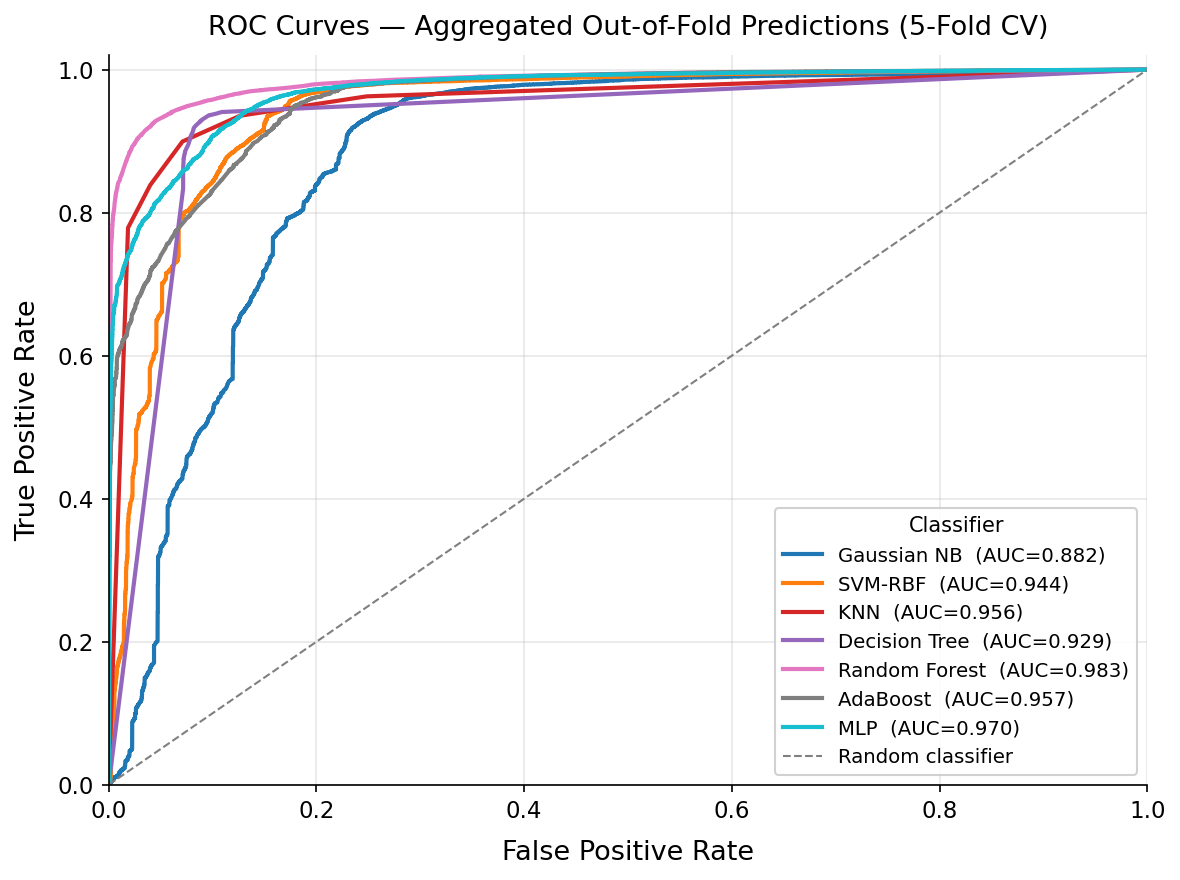

Figure 1 saved (PNG + PDF)


In [14]:
# Figure 1: ROC curves — AGGREGATED out-of-fold predictions (paper §IV-B, revised)
# NOTE (paper Figure 1 caption, revised): These are computed from concatenated
# out-of-fold predictions, NOT the arithmetic mean of per-fold ROC curves.
fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 0.9, len(models)))

for (name, _), col in zip(models.items(), colors):
    yt_all = np.concatenate([f[0] for f in fold_store[name]])
    yp_lst = [f[2] for f in fold_store[name] if f[2] is not None]
    if not yp_lst: continue
    yp_all = np.concatenate(yp_lst)
    fpr_a, tpr_a, _ = roc_curve(yt_all, yp_all)
    auc_v = auc(fpr_a, tpr_a)
    ax.plot(fpr_a, tpr_a, lw=2, color=col, label=f"{name}  (AUC={auc_v:.3f})")

ax.plot([0,1],[0,1], "--", lw=1, color="gray", label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=13, labelpad=8)
ax.set_ylabel("True Positive Rate",  fontsize=13, labelpad=8)
ax.set_title("ROC Curves — Aggregated Out-of-Fold Predictions (5-Fold CV)",
             fontsize=13, pad=10)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
ax.legend(loc="lower right", fontsize=9.5, title="Classifier",
          title_fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(f"{OUT_DIR}/figure1_roc_curves.{ext}", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 1 saved (PNG + PDF)")


In [15]:
# Table 5: Aggregated confusion matrices (all out-of-fold predictions)
# Paper §IV-C revised: "raw confusion matrix counts are normalized to N=600
# per model for proportional comparison. The absolute counts across all
# all out-of-fold predictions are used to compute the metrics."

agg_rows = []
for name in models:
    yt = np.concatenate([f[0] for f in fold_store[name]])
    yp = np.concatenate([f[1] for f in fold_store[name]])
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
    n = int(tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    rec  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1v  = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else np.nan

    # Normalized to N=600 (proportional scaling for paper Table 5)
    scale = 600 / n if n > 0 else 1
    agg_rows.append({
        "Model"    : name,
        "N (raw)"  : n,
        "N (norm)" : 600,
        # Normalized counts (paper Table 5)
        "TN_600": int(round(tn * scale)),
        "FP_600": int(round(fp * scale)),
        "FN_600": int(round(fn * scale)),
        "TP_600": int(round(tp * scale)),
        # Raw counts
        "TN_raw": int(tn), "FP_raw": int(fp),
        "FN_raw": int(fn), "TP_raw": int(tp),
        # Metrics (computed from raw counts)
        "Accuracy" : (tp+tn)/n,
        "Precision": prec, "Recall": rec, "F1": f1v,
        "FNR": fn/(fn+tp) if (fn+tp)>0 else np.nan,
        "FPR": fp/(fp+tn) if (fp+tn)>0 else np.nan,
    })

agg_cm_df = pd.DataFrame(agg_rows).sort_values("F1", ascending=False)
agg_cm_df.to_csv(f"{OUT_DIR}/aggregated_confusion_metrics.csv", index=False)

# Display normalized view (matches paper Table 5)
norm_cols = ["Model","N (norm)","TN_600","FP_600","FN_600","TP_600",
             "Accuracy","Precision","Recall","F1","FPR"]
print("Table 5 -- Aggregated Confusion Matrix (normalized to N=600)")
print("NOTE: TN/FP/FN/TP are proportionally scaled to N=600 for display.")
print(f"      Metrics are computed from the full {agg_cm_df['N (raw)'].iloc[0]:,} out-of-fold predictions.")
display(
    agg_cm_df[norm_cols].style
    .format({c: "{:.3f}" for c in ["Accuracy","Precision","Recall","F1","FNR","FPR"]
             if c in norm_cols})
    .highlight_max(subset=["F1","Accuracy"], color="lightgreen")
    .highlight_min(subset=["FPR"],           color="lightgreen")
)

# Per-class classification report for ALL models (reviewer requirement)
print("\n" + "=" * 65)
print("Per-class classification reports (all models)")
print("=" * 65)
for name in results_df["Model"]:
    yt_m = np.concatenate([f[0] for f in fold_store[name]])
    yp_m = np.concatenate([f[1] for f in fold_store[name]])
    print(f"\n--- {name} ---")
    print(classification_report(yt_m, yp_m,
          target_names=["Legitimate (0)", "Phishing (1)"], digits=3))

print(f"Saved: {OUT_DIR}/aggregated_confusion_metrics.csv")


Table 5 -- Aggregated Confusion Matrix (normalized to N=600)
NOTE: TN/FP/FN/TP are proportionally scaled to N=600 for display.
      Metrics are computed from the full 40,000 out-of-fold predictions.


,Model,N (norm),TN_600,FP_600,FN_600,TP_600,Accuracy,Precision,Recall,F1,FPR
4,Random Forest,600,284,16,20,280,0.941,0.946,0.935,0.940,0.053
3,Decision Tree,600,273,27,21,279,0.920,0.912,0.930,0.921,0.089
2,KNN,600,279,21,30,270,0.914,0.927,0.899,0.913,0.071
6,MLP,600,260,40,17,283,0.904,0.875,0.943,0.908,0.135
1,SVM-RBF,600,251,49,17,283,0.889,0.852,0.942,0.894,0.164
5,AdaBoost,600,246,54,15,285,0.885,0.841,0.949,0.892,0.179
0,Gaussian NB,600,195,105,8,292,0.812,0.736,0.973,0.838,0.349



Per-class classification reports (all models)

--- Random Forest ---
                precision    recall  f1-score   support

Legitimate (0)      0.935     0.947     0.941     20000
  Phishing (1)      0.946     0.935     0.940     20000

      accuracy                          0.941     40000
     macro avg      0.941     0.941     0.941     40000
  weighted avg      0.941     0.941     0.941     40000


--- Decision Tree ---
                precision    recall  f1-score   support

Legitimate (0)      0.928     0.910     0.919     20000
  Phishing (1)      0.912     0.930     0.921     20000

      accuracy                          0.920     40000
     macro avg      0.920     0.920     0.920     40000
  weighted avg      0.920     0.920     0.920     40000


--- KNN ---
                precision    recall  f1-score   support

Legitimate (0)      0.902     0.929     0.915     20000
  Phishing (1)      0.927     0.899     0.913     20000

      accuracy                          0.914 

In [16]:
# Train RF on full dataset then compute permutation importance
rf_full = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=N_ESTIMATORS,
                                     random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_full.fit(X, y)

perm = permutation_importance(
    rf_full, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

imp_df = (
    pd.DataFrame({
        "feature"        : FEATURE_NAMES,
        "importance_mean": perm.importances_mean,
        "importance_std" : perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
imp_df.index    += 1
imp_df.index.name = "Rank"
imp_df.to_csv(f"{OUT_DIR}/rf_permutation_importance.csv")

print("Table 6 -- Permutation Feature Importance (d=15)")
display(
    imp_df.style
    .format({"importance_mean": "{:.4f}", "importance_std": "{:.4f}"})
    .highlight_max(subset=["importance_mean"], color="lightyellow")
)

n_marginal = int((imp_df["importance_mean"] <= 0.002).sum())
print(f"\n{n_marginal}/{len(imp_df)} features with mean importance <= 0.002 (marginal)")
print(f"Top-4 features: {imp_df.head(4)['feature'].tolist()}")
print(f"Saved: {OUT_DIR}/rf_permutation_importance.csv")


Table 6 -- Permutation Feature Importance (d=15)


,feature,importance_mean,importance_std
Rank,,,
1,n_links,0.1997,0.0017
2,n_scripts,0.1406,0.0019
3,n_images,0.0820,0.0008
4,title_len,0.0809,0.0010
5,n_iframes,0.0569,0.0006
6,text_len,0.0424,0.0005
7,word_count,0.0293,0.0009
8,n_inputs,0.0270,0.0006
9,n_external_links,0.0225,0.0009



3/15 features with mean importance <= 0.002 (marginal)
Top-4 features: ['n_links', 'n_scripts', 'n_images', 'title_len']
Saved: results/rf_permutation_importance.csv


## § 13 — SHAP Analysis — Revised for Reviewers

This section produces:

- **Figure 2**: Global SHAP summary for the phishing-class output of the Random Forest model.
- **Figure 3a**: SHAP summary for the **phishing class**.
- **Figure 3b**: SHAP summary for the **legitimate class**.
- **Figure 4**: SHAP dependence plots for the top-3 phishing-ranked features.

This revision addresses the reviewer request for:

1. **Per-class SHAP analysis** (phishing vs. legitimate), and  
2. **Dependence plots** for the top 2–3 most important features.

Figure 2 -- Global SHAP summary (phishing-class output)


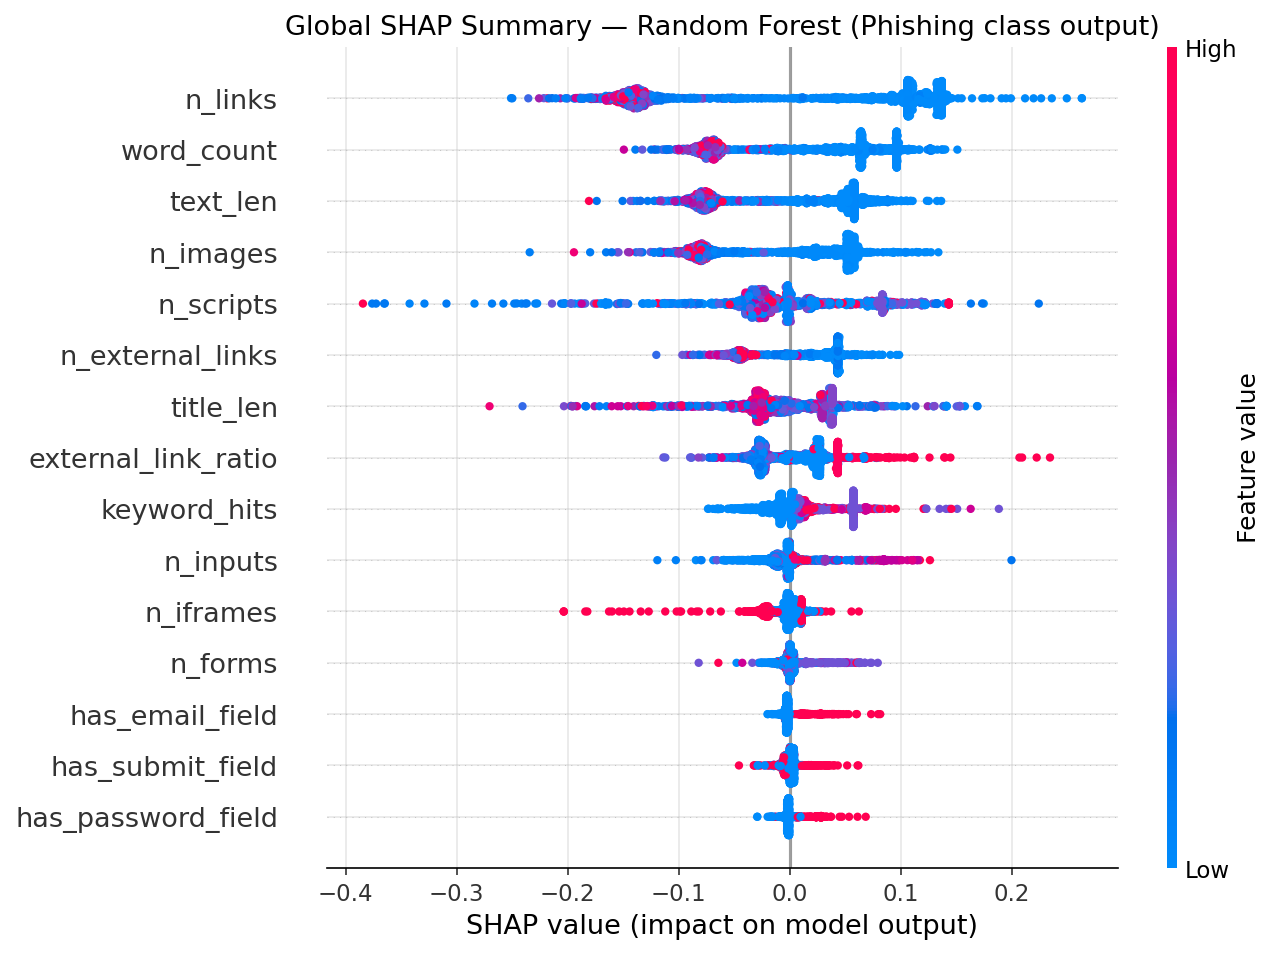

Saved: figure2_shap_global.png / .pdf


In [17]:
# Prepare transformed data for SHAP
X_trans = rf_full.named_steps["preprocess"].transform(X)
rf_model = rf_full.named_steps["model"]

if hasattr(X_trans, "toarray"):
    X_trans = X_trans.toarray()

sample_n = min(2000, X_trans.shape[0])
idx_s = np.random.choice(X_trans.shape[0], size=sample_n, replace=False)
X_s = X_trans[idx_s]
y_s = y.values[idx_s]

explainer = shap.TreeExplainer(rf_model)
shap_raw = explainer.shap_values(X_s)

def _extract_class_shap(shap_values, class_idx):
    '''
    Supports both common SHAP formats:
    - list: [class0, class1]
    - ndarray: (n_samples, n_features, n_classes)
    - ndarray: (n_samples, n_features) for collapsed binary outputs
    '''
    if isinstance(shap_values, list):
        return shap_values[class_idx]
    if isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            return shap_values[:, :, class_idx]
        if shap_values.ndim == 2:
            return shap_values
    raise ValueError(
        f"Unsupported SHAP output format: type={type(shap_values)}, "
        f"shape={getattr(shap_values, 'shape', None)}"
    )

# Class-specific SHAP values
shap_legit = _extract_class_shap(shap_raw, 0)   # legitimate class
shap_phish = _extract_class_shap(shap_raw, 1)   # phishing class

# Figure 2 -- Global SHAP summary using phishing-class output
print("Figure 2 -- Global SHAP summary (phishing-class output)")
shap.summary_plot(
    shap_phish,
    X_s,
    feature_names=TRANSFORMED_NAMES,
    show=False,
    plot_size=(9, 6.5),
    max_display=15
)
plt.title("Global SHAP Summary — Random Forest (Phishing class output)", fontsize=13)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(f"{OUT_DIR}/figure2_shap_global.{ext}", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure2_shap_global.png / .pdf")

Figure 3a -- SHAP summary for phishing class


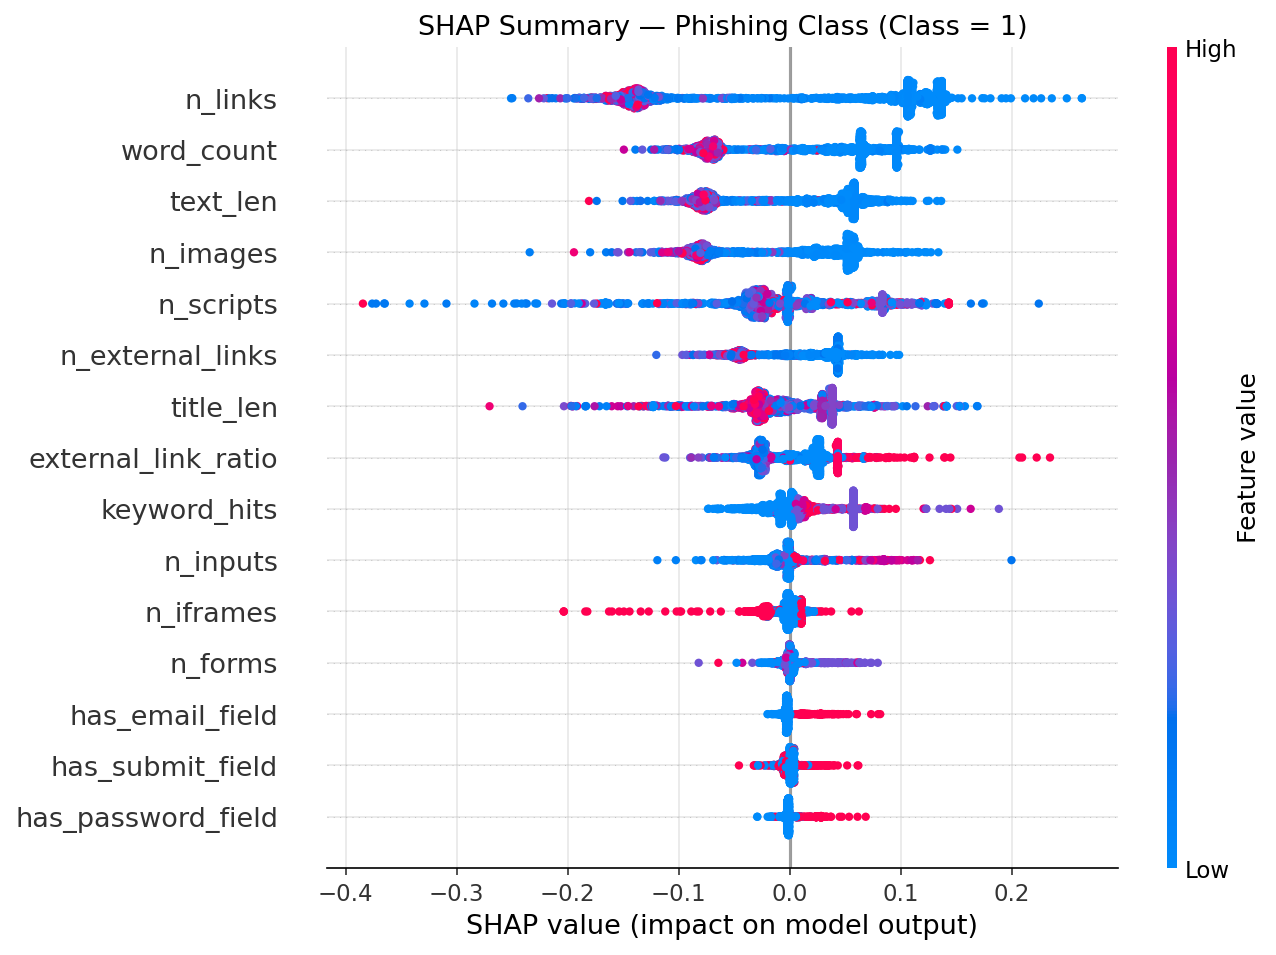

Figure 3b -- SHAP summary for legitimate class


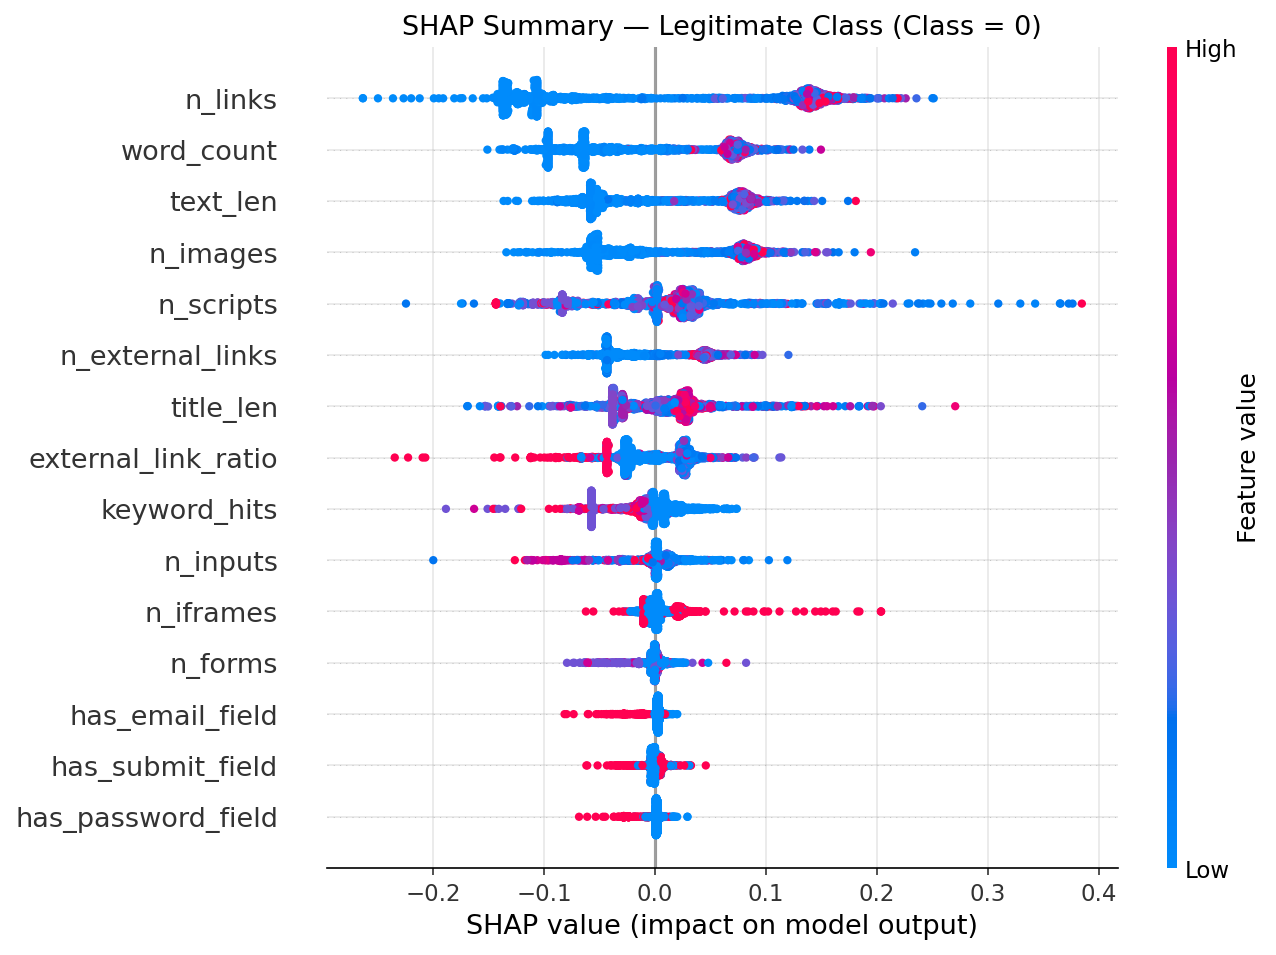

Saved: figure3a_shap_phishing_class.* and figure3b_shap_legitimate_class.*

Top features by phishing-class SHAP:


,feature,mean_abs_shap_legitimate,mean_abs_shap_phishing
0,n_links,0.119767,0.119767
1,word_count,0.066998,0.066998
2,text_len,0.061388,0.061388
3,n_images,0.058313,0.058313
4,n_scripts,0.045306,0.045306
5,n_external_links,0.037989,0.037989
6,title_len,0.033604,0.033604
7,external_link_ratio,0.029148,0.029148
8,keyword_hits,0.020685,0.020685
9,n_inputs,0.014081,0.014081


Saved: results/shap_perclass_importance.csv


In [18]:
# Figure 3a / 3b -- Per-class SHAP summaries
print("Figure 3a -- SHAP summary for phishing class")
shap.summary_plot(
    shap_phish,
    X_s,
    feature_names=TRANSFORMED_NAMES,
    show=False,
    plot_size=(9, 6.5),
    max_display=15
)
plt.title("SHAP Summary — Phishing Class (Class = 1)", fontsize=13)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(f"{OUT_DIR}/figure3a_shap_phishing_class.{ext}", dpi=300, bbox_inches="tight")
plt.show()

print("Figure 3b -- SHAP summary for legitimate class")
shap.summary_plot(
    shap_legit,
    X_s,
    feature_names=TRANSFORMED_NAMES,
    show=False,
    plot_size=(9, 6.5),
    max_display=15
)
plt.title("SHAP Summary — Legitimate Class (Class = 0)", fontsize=13)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(f"{OUT_DIR}/figure3b_shap_legitimate_class.{ext}", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure3a_shap_phishing_class.* and figure3b_shap_legitimate_class.*")

# Per-class mean absolute SHAP importance table
perclass_imp = pd.DataFrame({
    "feature": TRANSFORMED_NAMES,
    "mean_abs_shap_legitimate": np.abs(shap_legit).mean(axis=0),
    "mean_abs_shap_phishing": np.abs(shap_phish).mean(axis=0),
}).sort_values("mean_abs_shap_phishing", ascending=False).reset_index(drop=True)

perclass_imp.to_csv(f"{OUT_DIR}/shap_perclass_importance.csv", index=False)
print("\nTop features by phishing-class SHAP:")
display(perclass_imp.head(15))
print(f"Saved: {OUT_DIR}/shap_perclass_importance.csv")

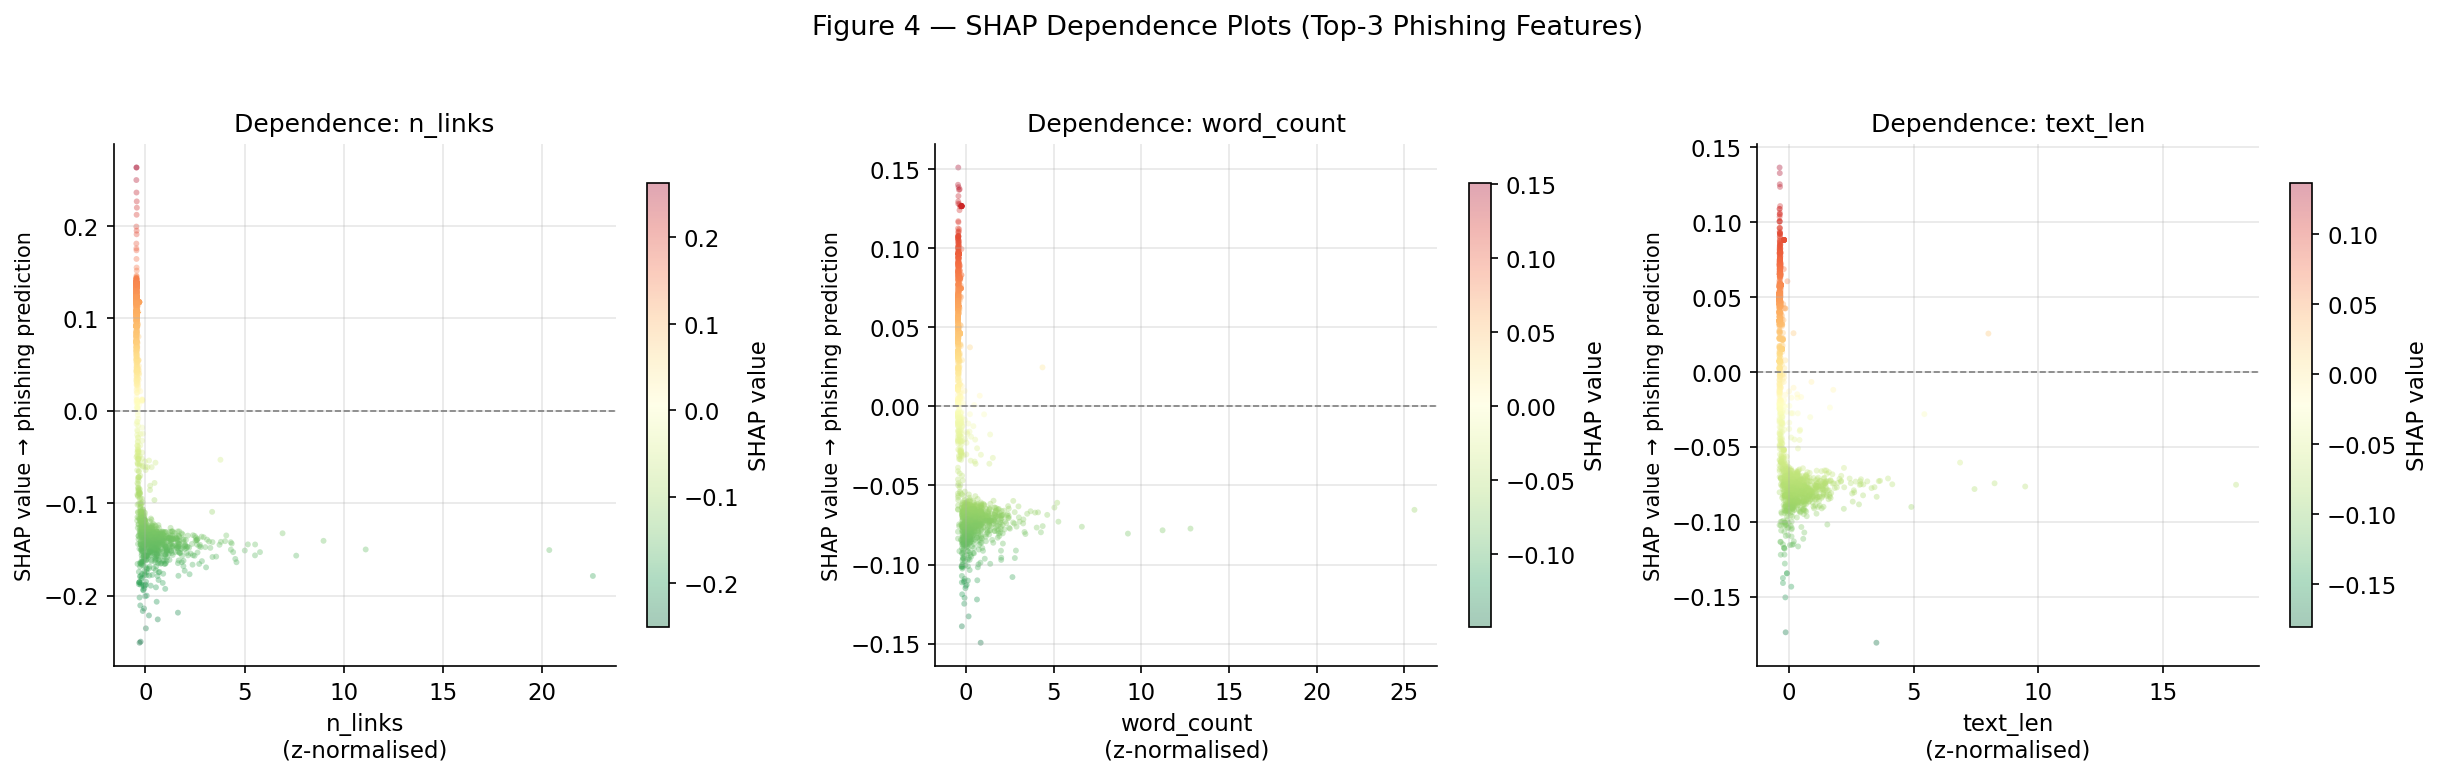

Saved: figure4_shap_dependence_top3.png
Top-3 phishing-ranked features: ['n_links', 'word_count', 'text_len']


In [19]:
# Figure 4 -- SHAP dependence plots for top-3 phishing-ranked features
top3 = perclass_imp.head(3)["feature"].tolist()
top3_i = [TRANSFORMED_NAMES.index(f) for f in top3 if f in TRANSFORMED_NAMES]

fig, axes = plt.subplots(1, len(top3_i), figsize=(5.5 * len(top3_i), 5))
if len(top3_i) == 1:
    axes = [axes]

for ax, fi in zip(axes, top3_i):
    fname = TRANSFORMED_NAMES[fi]
    x_vals = X_s[:, fi]
    sv = shap_phish[:, fi]

    sc = ax.scatter(
        x_vals, sv, c=sv, cmap="RdYlGn_r",
        alpha=0.35, s=8, linewidths=0
    )
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xlabel(f"{fname}\n(z-normalised)", fontsize=11)
    ax.set_ylabel("SHAP value → phishing prediction", fontsize=10)
    ax.set_title(f"Dependence: {fname}", fontsize=12)
    plt.colorbar(sc, ax=ax, label="SHAP value", shrink=0.85)

plt.suptitle("Figure 4 — SHAP Dependence Plots (Top-3 Phishing Features)",
             fontsize=13, y=1.03)
plt.tight_layout()
for ext in ("png",):
    plt.savefig(f"{OUT_DIR}/figure4_shap_dependence_top3.{ext}", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure4_shap_dependence_top3.png")
print("Top-3 phishing-ranked features:", top3)

In [20]:
# Table 7: Ablation study -- RF with reduced feature subsets
ranked = imp_df["feature"].tolist()
subsets = {
    "Top-3" : ranked[:3],
    "Top-5" : ranked[:5],
    "Top-8" : ranked[:8],
    "All-15": ranked,
}
abl_rows = []
print("Ablation study -- Random Forest, reduced feature subsets")
print("-" * 60)

for sname, fsub in subsets.items():
    bin_s = [f for f in fsub if f in BINARY_FEATURES]
    con_s = [f for f in fsub if f not in BINARY_FEATURES]
    trans = [("cont",
              Pipeline([("imp", SimpleImputer(strategy="median")),
                        ("sc",  StandardScaler())]),
              con_s)]
    if bin_s:
        trans.append(("bin", SimpleImputer(strategy="most_frequent"), bin_s))
    pre_s = ColumnTransformer(transformers=trans, remainder="drop")
    X_sub = X[fsub]
    f1s, aucs = [], []
    for tr, te in skf.split(X_sub, y):
        p = Pipeline([("prep", pre_s),
                      ("model", RandomForestClassifier(n_estimators=N_ESTIMATORS,
                                random_state=RANDOM_STATE, n_jobs=-1))])
        p.fit(X_sub.iloc[tr], y.iloc[tr])
        yp = p.predict(X_sub.iloc[te])
        ypr = _get_proba(p, X_sub.iloc[te])
        f1s.append(f1_score(y.iloc[te], yp, average='binary', pos_label=1, zero_division=0))
        if ypr is not None:
            aucs.append(roc_auc_score(y.iloc[te], ypr))
    row = {"Subset": sname, "# Features": len(fsub),
           "Mean F1": np.mean(f1s), "F1 Std": np.std(f1s),
           "Mean AUC": np.mean(aucs) if aucs else np.nan,
           "AUC Std": np.std(aucs) if aucs else np.nan}
    abl_rows.append(row)
    print(f"  {sname:8s} (d={len(fsub):2d})  "
          f"F1={row['Mean F1']:.3f}+-{row['F1 Std']:.3f}  "
          f"AUC={row['Mean AUC']:.3f}+-{row['AUC Std']:.3f}")

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv(f"{OUT_DIR}/ablation_study.csv", index=False)
print("\nTable 7:")
display(
    abl_df[["Subset","# Features","Mean F1","F1 Std","Mean AUC","AUC Std"]]
    .style.format({c: "{:.3f}" for c in ["Mean F1","F1 Std","Mean AUC","AUC Std"]})
    .highlight_max(subset=["Mean F1","Mean AUC"], color="lightgreen")
)
print(f"Saved: {OUT_DIR}/ablation_study.csv")


Ablation study -- Random Forest, reduced feature subsets
------------------------------------------------------------
  Top-3    (d= 3)  F1=0.908+-0.002  AUC=0.970+-0.001
  Top-5    (d= 5)  F1=0.926+-0.003  AUC=0.977+-0.002
  Top-8    (d= 8)  F1=0.937+-0.002  AUC=0.982+-0.001
  All-15   (d=15)  F1=0.941+-0.002  AUC=0.983+-0.001

Table 7:


,Subset,# Features,Mean F1,F1 Std,Mean AUC,AUC Std
0,Top-3,3,0.908,0.002,0.970,0.001
1,Top-5,5,0.926,0.003,0.977,0.002
2,Top-8,8,0.937,0.002,0.982,0.001
3,All-15,15,0.941,0.002,0.983,0.001


Saved: results/ablation_study.csv


In [21]:
# Qualitative error analysis (paper §IV-G)
best_name = results_df.iloc[0]["Model"]
all_te, all_yt, all_yp = [], [], []
for fi, (_, te) in enumerate(skf.split(X, y)):
    yt_f, yp_f, _ = fold_store[best_name][fi]
    all_te.extend(te.tolist())
    all_yt.extend(yt_f.tolist())
    all_yp.extend(yp_f.tolist())

err = df.iloc[all_te].copy().reset_index(drop=True)
err["y_true"] = all_yt
err["y_pred"]  = all_yp
err["etype"]   = "correct"
err.loc[(err.y_true==1)&(err.y_pred==0), "etype"] = "FN"
err.loc[(err.y_true==0)&(err.y_pred==1), "etype"] = "FP"

fn_df = err[err.etype == "FN"]
fp_df = err[err.etype == "FP"]
tp_df = err[(err.y_true==1)&(err.y_pred==1)]
tn_df = err[(err.y_true==0)&(err.y_pred==0)]

print(f"Error analysis -- {best_name}")
print(f"  False Negatives (missed phishing)   : {len(fn_df):,}")
print(f"  False Positives (flagged legitimate): {len(fp_df):,}")
print(f"  True Positives  (detected phishing) : {len(tp_df):,}")
print(f"  True Negatives  (correct legitimate): {len(tn_df):,}")

profile = pd.DataFrame({
    "FN (missed phishing)" : fn_df[FEATURE_NAMES].mean(),
    "FP (false alarm)"     : fp_df[FEATURE_NAMES].mean(),
    "TP (detected)"        : tp_df[FEATURE_NAMES].mean(),
    "TN (correct legit)"   : tn_df[FEATURE_NAMES].mean(),
}).round(3)
print("\nFeature profile by error type:")
display(profile)

fn_df.to_csv(f"{OUT_DIR}/false_negatives.csv", index=False)
fp_df.to_csv(f"{OUT_DIR}/false_positives.csv", index=False)
print(f"Saved: false_negatives.csv  |  false_positives.csv")


Error analysis -- Random Forest
  False Negatives (missed phishing)   : 1,306
  False Positives (flagged legitimate): 1,061
  True Positives  (detected phishing) : 18,694
  True Negatives  (correct legitimate): 18,939

Feature profile by error type:


,FN (missed phishing),FP (false alarm),TP (detected),TN (correct legit)
text_len,2241.224,371.909,415.844,7230.350
word_count,317.698,44.079,47.933,1086.115
title_len,29.152,18.309,25.519,43.463
keyword_hits,0.518,0.254,0.498,1.035
n_scripts,13.262,5.987,16.048,25.303
n_images,11.089,0.943,1.063,48.223
n_forms,0.472,0.210,0.208,1.142
n_inputs,2.209,0.906,1.723,5.483
n_iframes,0.247,0.074,0.237,0.564
has_password_field,0.050,0.076,0.101,0.051


Saved: false_negatives.csv  |  false_positives.csv


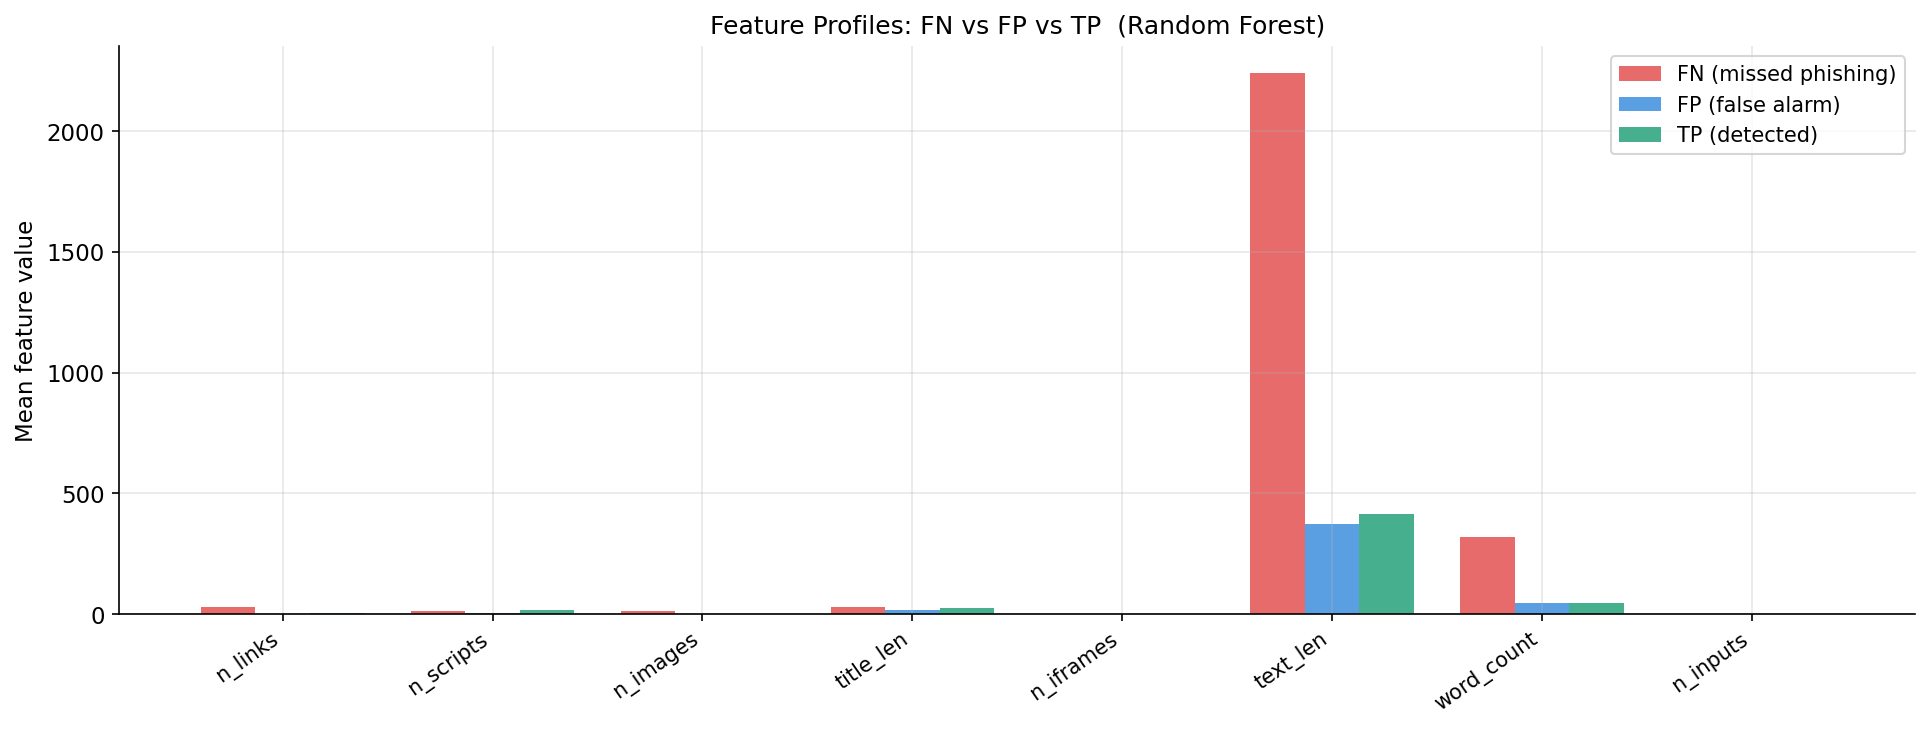

Saved: figure3_error_profiles.png


In [22]:
# Figure 3 -- Error feature profile comparison
top8 = imp_df.head(8)["feature"].tolist()
groups = [
    ("FN (missed phishing)", fn_df, "#E24B4A"),
    ("FP (false alarm)",     fp_df, "#378ADD"),
    ("TP (detected)",        tp_df, "#1D9E75"),
]
x     = np.arange(len(top8))
width = 0.26
fig, ax = plt.subplots(figsize=(13, 5))
for offset, (label, gdf, col) in zip([-1, 0, 1], groups):
    ax.bar(x + offset * width, gdf[top8].mean().values, width,
           label=label, color=col, alpha=0.82, edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(top8, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Mean feature value", fontsize=11)
ax.set_title(f"Feature Profiles: FN vs FP vs TP  ({best_name})", fontsize=12)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figure3_error_profiles.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure3_error_profiles.png")


In [23]:
# Export all results to Excel + metadata JSON
xl_path = f"{OUT_DIR}/all_results.xlsx"
with pd.ExcelWriter(xl_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="Table4_CV_Results",     index=False)
    agg_cm_df.to_excel(writer,  sheet_name="Table5_ConfusionMatrix", index=False)
    imp_df.to_excel(writer,     sheet_name="Table6_Importance")
    abl_df.to_excel(writer,     sheet_name="Table7_Ablation",        index=False)
    pval_df.to_excel(writer,    sheet_name="Wilcoxon_pvalues")
    profile.to_excel(writer,    sheet_name="ErrorAnalysis")

# Dynamic package version detection
import sklearn
meta = {
    "paper"           : "Beyond URL Analysis -- Al-Haj et al. AITA Journal",
    "collection_date" : COLLECTION_DATE,
    "target_per_class": TARGET_PER_CLASS,
    "n_phishing"      : int((y == 1).sum()),
    "n_legitimate"    : int((y == 0).sum()),
    "n_total"         : len(df),
    "class_ratio"     : f"{int((y==0).sum())/len(df)*100:.1f}% legit / {int((y==1).sum())/len(df)*100:.1f}% phish",
    "feature_dim"     : len(FEATURE_NAMES),
    "features"        : FEATURE_NAMES,
    "n_folds"         : N_FOLDS,
    "random_state"    : RANDOM_STATE,
    "packages": {
        "python"         : sys.version.split()[0],
        "scikit-learn"   : sklearn.__version__,
        "numpy"          : np.__version__,
        "pandas"         : pd.__version__,
        "beautifulsoup4" : __import__('bs4').__version__,
        "requests"       : requests.__version__,
        "shap"           : shap.__version__,
        "scipy"          : __import__('scipy').__version__,
        "tldextract"     : tldextract.__version__,
    },
    "collection_stats": stats,
}
with open(f"{OUT_DIR}/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

# File listing
print("All outputs saved to:", OUT_DIR)
print()
for fname in sorted(os.listdir(OUT_DIR)):
    fpath = os.path.join(OUT_DIR, fname)
    kb    = os.path.getsize(fpath) / 1024
    print(f"  {fname:55s}  {kb:7.1f} KB")

# Final summary
best = results_df.iloc[0]
print("\n" + "=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
print(f"  Best model    : {best['Model']}")
print(f"  F1-score      : {best['F1']:.3f} +- {best['F1_std']:.3f}")
print(f"  ROC-AUC       : {best['ROC_AUC']:.3f} +- {best['ROC_AUC_std']:.3f}")
print(f"  FNR / FPR     : {best['FNR']:.3f}  /  {best['FPR']:.3f}")
print(f"  Top-4 features: {imp_df.head(4)['feature'].tolist()}")
print(f"  Marginal feats: {n_marginal}/{len(FEATURE_NAMES)} (importance <= 0.002)")
print(f"  Dataset total : {len(df):,} pages "
      f"({int((y==1).sum()):,} phishing / {int((y==0).sum()):,} legitimate)")
print()
print(">>> IMPORTANT: Copy the numbers above to update the paper tables <<<")


All outputs saved to: results

  _checkpoint.csv                                           6143.5 KB
  ablation_study.csv                                           0.4 KB
  aggregated_confusion_metrics.csv                             1.0 KB
  all_results.xlsx                                            11.9 KB
  errors.csv                                                 785.1 KB
  false_negatives.csv                                        230.1 KB
  false_positives.csv                                        101.3 KB
  figure1_roc_curves.pdf                                      52.3 KB
  figure1_roc_curves.png                                     283.5 KB
  figure2_shap_global.pdf                                    224.8 KB
  figure2_shap_global.png                                    408.5 KB
  figure3_error_profiles.png                                 148.7 KB
  figure3a_shap_phishing_class.pdf                           228.0 KB
  figure3a_shap_phishing_class.png                         

In [24]:
# Download all results as ZIP
import os
import zipfile

if "OUT_DIR" not in globals():
    OUT_DIR = "results"

if not os.path.exists(OUT_DIR):
    raise FileNotFoundError(f"Output directory not found: {OUT_DIR}")

zip_path = os.path.join(os.getcwd(), "phishing_detection_results.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files_in_dir in os.walk(OUT_DIR):
        for fname in sorted(files_in_dir):
            fpath = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, OUT_DIR)
            zf.write(fpath, arcname)

print(f"ZIP created successfully: {zip_path}")
print("You can now upload this ZIP to GitHub or keep it as an archive.")


ZIP created successfully: /Users/marwan/Downloads/Telegram Lite/phishing_detection_results.zip
You can now upload this ZIP to GitHub or keep it as an archive.
